In [ ]:
# release DepMap Public 26Q1 Files

In [5]:
import numpy, os
import pandas
import matplotlib.pyplot
import matplotlib.patches

%matplotlib inline
matplotlib.pyplot.rcParams['figure.dpi'] = 150

In [16]:
# load data
models = pandas.read_csv('Model.csv', low_memory=False)
expr = pandas.read_csv('OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv')

print(f'Models: {models.shape}')
print(f'Expression matrix: {expr.shape}')
print(expr.columns[:6].tolist())

Models: (2154, 49)
Expression matrix: (1775, 19221)
['Unnamed: 0', 'SequencingID', 'ModelConditionID', 'ModelID', 'IsDefaultEntryForMC', 'IsDefaultEntryForModel']


,Unnamed: 0,SequencingID,ModelConditionID,ModelID,IsDefaultEntryForMC,IsDefaultEntryForModel,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),...,ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
0,0,CDS-010xbm,MC-001113-k2lR,ACH-001113,Yes,Yes,4.956577,0.000000,7.577648,3.179411,...,0.0,0.000000,0.414727,0.077634,1.113094,0.411901,0.0,5.134808,1.214541,4.315653
1,1,CDS-02TzJp,MC-001289-BpdI,ACH-001289,Yes,Yes,4.955015,0.617117,7.333933,2.782935,...,0.0,0.000000,0.029809,0.000000,1.269267,1.026807,0.0,5.953793,0.006969,4.250636
2,2,CDS-0693hw,MC-001339-5nRN,ACH-001339,Yes,Yes,3.421952,0.000000,7.546069,2.615880,...,0.0,0.000000,0.127768,0.105594,0.413829,0.540575,0.0,4.205971,0.030894,2.783448
3,3,CDS-07Plat,MC-001619-IR6I,ACH-001619,No,No,5.196729,0.000000,6.362268,2.144996,...,0.0,0.000000,0.075396,0.932918,0.000000,0.511978,0.0,4.510747,3.223597,5.106596
4,4,CDS-08FOcu,MC-001979-E3qW,ACH-001979,Yes,Yes,4.651643,0.000000,5.946408,2.454515,...,0.0,0.000000,0.012012,0.000000,1.006470,0.729221,0.0,4.922916,0.150926,4.661556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1770,1770,CDS-zsS3zE,MC-002669-Ivra,ACH-002669,Yes,Yes,3.770702,0.000000,7.380245,1.803405,...,0.0,0.000000,0.032260,0.890296,0.185355,0.211497,0.0,5.602071,0.000000,7.062305
1771,1771,CDS-zsp0NA,MC-001858-c43i,ACH-001858,Yes,Yes,4.886794,0.000000,7.245943,2.187771,...,0.0,0.000000,1.727733,0.311457,0.179430,0.468641,0.0,5.290513,0.030359,5.632410
1772,1772,CDS-zvrgDc,MC-001997-n8wz,ACH-001997,Yes,Yes,5.721963,0.000000,8.299822,3.008067,...,0.0,0.000000,0.002292,2.102581,0.005078,0.382775,0.0,4.417501,0.008285,5.242202
1773,1773,CDS-zvw4zv,MC-003297-yuio,ACH-003297,Yes,Yes,5.614041,0.000000,9.594667,2.666827,...,0.0,0.000000,1.049101,0.000000,0.000000,1.011853,0.0,5.329231,0.000001,4.132692


In [19]:
mitf_cols = [c for c in expr.columns if c.startswith('MITF (')]
print(f'MITF column found: {mitf_cols}')

MITF column found: ['MITF (4286)']


In [22]:
# Clean and sort

id_to_name = dict(zip(models['ModelID'], models['CellLineName']))

df_raw = pandas.DataFrame({
    'ModelID':    expr['ModelID'],
    'expression': expr[mitf_col].values
})

df_raw['CellLineName'] = df_raw['ModelID'].map(id_to_name).fillna(df_raw['ModelID'])
df_raw = df_raw.dropna(subset=['expression'])

# Collapse duplicates, keep count
df = df_raw.groupby('CellLineName')['expression'].agg(
    expression='median',
    n_measurements='count'
).reset_index()

df = df.sort_values('expression', ascending=False).reset_index(drop=True)

print(f'Total cell lines after collapsing duplicates: {len(df)}')
df.head(10)

Total cell lines after collapsing duplicates: 1719


,CellLineName,expression,n_measurements
0,MM473,8.734954,1
1,MA-MEL-27,8.680877,1
2,MM466,8.475863,1
3,NZM12,8.216168,1
4,Hs 936.T,8.210754,1
5,IGR-37,8.189878,1
6,HMY-1,8.175205,1
7,MM576,8.133291,1
8,G-361,8.107985,1
9,Omm1,8.075864,1


In [25]:
# Flag cell lines of interest

synonyms = {
    'HeLa':   ['HeLa', 'HELA', 'HeLa-S3'],
    'U2OS':   ['U2OS', 'U-2OS', 'U2-OS'],
    'A549':   ['A549', 'A-549'],
    'D492':   ['D492', 'D-492'],
    'SW1353': ['SW1353', 'SW-1353', 'SW 1353'],
}

def norm(s):
    return s.upper().replace('-', '').replace('_', '').replace(' ', '')

for canonical, syn_list in synonyms.items():
    syn_norm = [norm(s) for s in syn_list]
    matches = df[df['CellLineName'].apply(lambda n: norm(n) in syn_norm)]
    if len(matches) > 0:
        print(f'FOUND    {canonical:10s}: {matches["CellLineName"].tolist()}  expression = {matches["expression"].round(3).tolist()}')
    else:
        print(f'MISSING  {canonical}')

FOUND    HeLa      : ['HeLa']  expression = [3.896]
FOUND    U2OS      : ['U-2 OS']  expression = [2.512]
FOUND    A549      : ['A549']  expression = [3.495]
MISSING  D492
FOUND    SW1353    : ['SW 1353']  expression = [5.853]


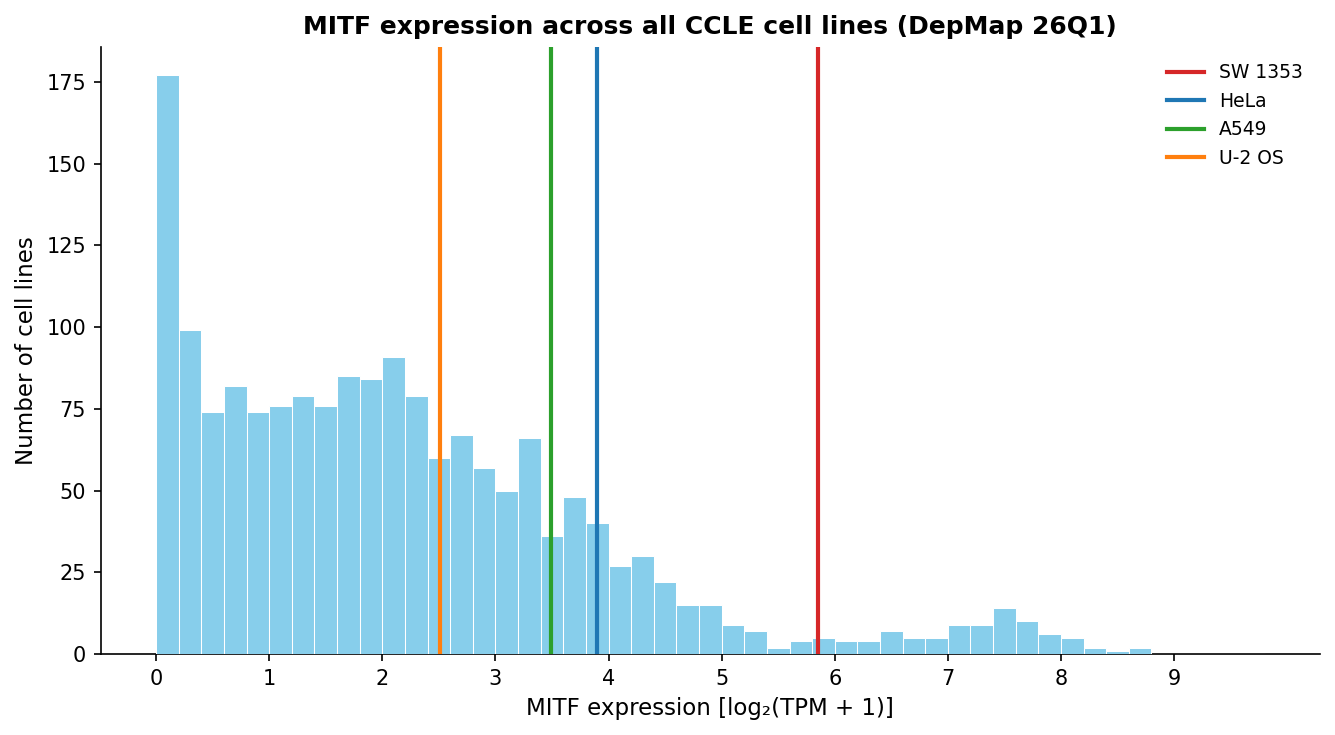

In [35]:
# Histogram

COLOUR_DEFAULT = 'skyblue'
tab10 = matplotlib.pyplot.get_cmap('tab10')
HIGHLIGHT_COLOURS = {
    'HeLa':   tab10(0),
    'U-2 OS':   tab10(1),
    'A549':   tab10(2),
    'SW 1353': tab10(3),
}

fig, ax = matplotlib.pyplot.subplots(figsize=(9, 5))

ax.hist(df['expression'], bins=numpy.arange(0, 10, 0.2), color=COLOUR_DEFAULT, edgecolor='white', linewidth=0.5, zorder=3)

for _, row in df[df['highlight']].iterrows():
    colour = HIGHLIGHT_COLOURS.get(row['CellLineName'], 'black')
    ax.axvline(x=row['expression'], color=colour,
               linewidth=2, zorder=4, label=row['CellLineName'])

ax.set_xlabel('MITF expression [log\u2082(TPM + 1)]', fontsize=11)
ax.set_ylabel('Number of cell lines', fontsize=11)
ax.set_title('MITF expression across all CCLE cell lines (DepMap 26Q1)', fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 10))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=9)

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.savefig('MITF_CCLE_histogram.pdf', bbox_inches='tight', dpi=300)
matplotlib.pyplot.savefig('MITF_CCLE_histogram.png', bbox_inches='tight', dpi=300)
matplotlib.pyplot.show()